In [127]:
import pandas as pd
import numpy as np
import gc
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

# ══════════════════════════════════════════════════════════════
#  1. LOAD DATA
# ══════════════════════════════════════════════════════════════

print("[INFO] Reading dataset...")
df = pd.read_csv("../combined_dataset2.csv")


gc.collect()


[INFO] Reading dataset...


33587

In [112]:
pd.set_option('display.max_columns', None)
print(df.head(5))

   Dst Port  Protocol  Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  \
0      80.0       6.0   5.773743e+06          38.0          29.0   
1   56428.0       6.0   1.000000e-03           1.0           0.0   
2      80.0       6.0   1.000000e-03           1.0           0.0   
3      80.0       6.0   1.000000e-03           1.0           0.0   
4      80.0       6.0   2.744203e+05           4.0           6.0   

   TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  Fwd Pkt Len Min  \
0           5008.0          31901.0            388.0             52.0   
1             52.0              0.0             52.0             52.0   
2             46.0              0.0             46.0             46.0   
3             46.0              0.0             46.0             46.0   
4            546.0           4178.0            388.0             46.0   

   Fwd Pkt Len Mean  Fwd Pkt Len Std  Bwd Pkt Len Max  Bwd Pkt Len Min  \
0        131.789474       142.736997           1500.0             52.0   
1   

In [128]:
# ══════════════════════════════════════════════════════════════
#  2. DROP COLUMNS
#     Keeping Dst Port — strong signal for attack classification
#     Keeping Fwd/Bwd Header Len — marginal but free to keep
# ══════════════════════════════════════════════════════════════

drop_cols = [
    # 1. Metadata / Identity Leakage (Always drop these)
    "Timestamp", "Flow ID", "Src IP", "Dst IP", "Src Port",
    "Protocol", "Dst Port",

    # 2. OS Fingerprints / Kernel Settings (Drop to prevent environment bias)
    'Init Fwd Win Byts', 
    'Init Bwd Win Byts', 
    'Fwd Seg Size Min',
    
    # 3. NIC / Driver Specifics (Drop to prevent hardware bias)
    'Fwd Header Len', 
    'Bwd Header Len',
    
    # 4. Automation Signatures / Script Timing (Drop to prevent CPU/timing bias)
    'Flow Duration',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'Fwd IAT Tot',  'Bwd IAT Tot' # Added Totals here as they track script duration
]

df.drop(columns=drop_cols, errors='ignore', inplace=True)
print(f"    Shape after drops: {df.shape}")
print(f"    Remaining features: {[c for c in df.columns if c != 'Label']}")
gc.collect()


    Shape after drops: (168573, 38)
    Remaining features: ['Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Bwd IAT Min', 'Fwd PSH Flags', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'ECE Flag Cnt', 'Down/Up Ratio', 'Fwd Act Data Pkts', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']


0

In [129]:

# ══════════════════════════════════════════════════════════════
#  3. CLEAN DATA
# ══════════════════════════════════════════════════════════════

print("[3] Cleaning data...")

# Replace infinity with NaN then drop
df.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(df)
df.dropna(inplace=True)
print(f"    Dropped {before - len(df)} rows with NaN/Inf")
print(df.columns)
gc.collect()

[3] Cleaning data...
    Dropped 11 rows with NaN/Inf
Index(['Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts',
       'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean',
       'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min',
       'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Pkt Len Min', 'Pkt Len Max',
       'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt',
       'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt',
       'ECE Flag Cnt', 'Down/Up Ratio', 'Fwd Act Data Pkts', 'Active Mean',
       'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std',
       'Idle Max', 'Idle Min', 'Label'],
      dtype='object')


0

In [130]:
# ══════════════════════════════════════════════════════════════
# 4. ENCODE LABELS
# ══════════════════════════════════════════════════════════════
print("[4] Encoding labels...") 
print(f" Class distribution:\n{df['Label'].value_counts()}")

le = LabelEncoder() 
y = le.fit_transform(df['Label'])

print(f"\n Label mapping:") 
for cls, idx in zip(le.classes_, range(len(le.classes_))): count = (df['Label'] == cls).sum() 
print(f" {idx:2d} → {cls:<30} ({count:,} samples)")
gc.collect()

[4] Encoding labels...
 Class distribution:
Label
DoS                      24761
Exploits                 20325
Benign                   16857
SSH-Bruteforce           13000
Bot                      13000
Reconnaissance           13000
DDOS attack-HOIC         13000
FTP-BruteForce           13000
Fuzzers                  13000
DoS attacks-GoldenEye    12452
DoS attacks-Slowloris     6903
Generic                   4632
Shellcode                 2102
Brute Force -Web           611
DDOS attack-LOIC-UDP       519
Backdoor                   452
Analysis                   385
Worms                      246
Brute Force -XSS           230
SQL Injection               87
Name: count, dtype: int64

 Label mapping:
 19 → Worms                          (246 samples)


0

In [131]:
# ══════════════════════════════════════════════════════════════
#  5. PREPARE FEATURES
# ══════════════════════════════════════════════════════════════

print("\n[5] Preparing features...")
df.drop(columns=['Label'], inplace=True)

feature_names = list(df.columns)  
joblib.dump(feature_names, 'feature_names.pkl')

# Convert any remaining object columns
for col in df.columns:
   if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Convert to float32 to save RAM
X = df.values.astype(np.float32)
del df
gc.collect()


[5] Preparing features...


0

In [132]:
# ── Clean AFTER float32 conversion ───────────────────────────
# float32 max value is ~3.4e38 — values above this become inf
# Clean in-place on numpy array (faster than pandas for large arrays)

print(f"    Inf values before clean: {np.isinf(X).sum()}")
print(f"    NaN values before clean: {np.isnan(X).sum()}")

# Replace inf and -inf with column max/min of finite values
# (better than replacing with 0 which distorts feature distributions)
for col_idx in range(X.shape[1]):
    col = X[:, col_idx]
    finite_mask = np.isfinite(col)

    if finite_mask.sum() == 0:
        # Entire column is inf/nan — set to 0
        X[:, col_idx] = 0
        continue

    col_max = col[finite_mask].max()
    col_min = col[finite_mask].min()

    # Replace +inf with column max, -inf with column min, nan with 0
    X[:, col_idx] = np.where(col == np.inf,  col_max, col)
    X[:, col_idx] = np.where(col == -np.inf, col_min, X[:, col_idx])
    X[:, col_idx] = np.where(np.isnan(X[:, col_idx]), 0, X[:, col_idx])

print(f"    Inf values after clean:  {np.isinf(X).sum()}")
print(f"    NaN values after clean:  {np.isnan(X).sum()}")

# Final hard clip — anything still extreme gets clipped to float32 safe range
X = np.clip(X, -3.4e38, 3.4e38)
gc.collect()

    Inf values before clean: 0
    NaN values before clean: 0
    Inf values after clean:  0
    NaN values after clean:  0


0

In [133]:
# ══════════════════════════════════════════════════════════════
#  6. SCALE
#     NOTE: XGBoost is tree-based and doesn't need scaling
#     BUT we scale anyway to keep compatibility with your
#     existing Scapy pipeline that uses the scaler
# ══════════════════════════════════════════════════════════════

print("[6] Scaling features...")
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
del X
gc.collect()

[6] Scaling features...


0

In [134]:
# ══════════════════════════════════════════════════════════════
#  7. TRAIN / TEST SPLIT
# ══════════════════════════════════════════════════════════════

print("[7] Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # ensures each class is proportionally represented
)
del X_scaled
gc.collect()

print(f"    Train: {X_train.shape}")
print(f"    Test:  {X_test.shape}")

[7] Splitting data...
    Train: (134849, 37)
    Test:  (33713, 37)


In [135]:
# ══════════════════════════════════════════════════════════════
#  8. CLASS WEIGHTS
#     No SMOTE — using sample weights instead
#     This tells XGBoost to penalize mistakes on rare classes more
# ══════════════════════════════════════════════════════════════

print("[8] Computing sample weights...")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Show effective weight per class
for i, cls in enumerate(le.classes_):
    mask = y_train == i
    if mask.sum() > 0:
        avg_w = sample_weights[mask].mean()
        print(f"    {cls:<30} n={mask.sum():>7,}  avg_weight={avg_w:.3f}")


[8] Computing sample weights...
    Analysis                       n=    308  avg_weight=21.891
    Backdoor                       n=    362  avg_weight=18.626
    Benign                         n= 13,485  avg_weight=0.500
    Bot                            n= 10,400  avg_weight=0.648
    Brute Force -Web               n=    489  avg_weight=13.788
    Brute Force -XSS               n=    184  avg_weight=36.644
    DDOS attack-HOIC               n= 10,400  avg_weight=0.648
    DDOS attack-LOIC-UDP           n=    415  avg_weight=16.247
    DoS                            n= 19,809  avg_weight=0.340
    DoS attacks-GoldenEye          n=  9,961  avg_weight=0.677
    DoS attacks-Slowloris          n=  5,522  avg_weight=1.221
    Exploits                       n= 16,260  avg_weight=0.415
    FTP-BruteForce                 n= 10,400  avg_weight=0.648
    Fuzzers                        n= 10,400  avg_weight=0.648
    Generic                        n=  3,705  avg_weight=1.820
    Reconnaissance

In [136]:
# ══════════════════════════════════════════════════════════════
#  9. BUILD XGBOOST MODEL
# ══════════════════════════════════════════════════════════════

feature_names = joblib.load('feature_names.pkl')

print("\n[9] Building XGBoost model...")

n_classes = len(le.classes_)

model = xgb.XGBClassifier(
    # ── Core parameters ──────────────────────────────────────
    n_estimators      = 450,     # number of trees
    max_depth         = 10,       # tree depth — deeper = more complex patterns
    learning_rate     = 0.06,    # shrinkage — lower = more robust but slower
    subsample         = 0.8,     # fraction of rows per tree — prevents overfit
    colsample_bytree  = 0.8,     # fraction of features per tree

    # ── Multi-class settings ──────────────────────────────────
    objective         = 'multi:softprob',
    num_class         = n_classes,
    eval_metric       = 'mlogloss',
    
    # ── Performance ───────────────────────────────────────────
    n_jobs            = -1,      # use all CPU cores
    tree_method       = 'hist',  # fastest CPU method
    #tree_method     = 'gpu_hist',  # uncomment if you have GPU in Colab

    # ── Regularization — prevents overfitting ─────────────────
    reg_alpha         = 0.1,     # L1 regularization
    reg_lambda        = 1.0,     # L2 regularization
    min_child_weight  = 5,       # minimum samples per leaf

    gamma             = 0.1,
    
    random_state      = 42,
    verbosity         = 1,
    feature_names = feature_names,
)

print(f"    Classes: {n_classes}")
print(f"    Features: {X_train.shape[1]}")


[9] Building XGBoost model...
    Classes: 20
    Features: 37


In [137]:
# ══════════════════════════════════════════════════════════════
#  10. TRAIN
# ══════════════════════════════════════════════════════════════

print("\n[10] Training XGBoost...")
print("     (500 trees × 8 depth — expect 5-15 min on CPU)")

model.fit(
    X_train, y_train,
    sample_weight     = sample_weights,
    eval_set          = [(X_test, y_test)],
    verbose           = 50,      
   
)

gc.collect()


[10] Training XGBoost...
     (500 trees × 8 depth — expect 5-15 min on CPU)


D:\InstalledApps\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:32:54] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_1777410317022\work\src\learner.cc:782: 
Parameters: { "feature_names" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-mlogloss:2.53848
[50]	validation_0-mlogloss:0.46064
[100]	validation_0-mlogloss:0.35821
[150]	validation_0-mlogloss:0.33825
[200]	validation_0-mlogloss:0.32965
[250]	validation_0-mlogloss:0.32516
[300]	validation_0-mlogloss:0.32269
[350]	validation_0-mlogloss:0.32123
[400]	validation_0-mlogloss:0.32036
[449]	validation_0-mlogloss:0.31962


21

In [138]:
# ══════════════════════════════════════════════════════════════
#  11. EVALUATE
# ══════════════════════════════════════════════════════════════

print("\n[11] Evaluating...")
y_pred = model.predict(X_test)

print("\n" + "="*65)
print("CLASSIFICATION REPORT")
print("="*65)
print(classification_report(y_test, y_pred, target_names=le.classes_))




[11] Evaluating...

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

             Analysis       0.49      0.94      0.64        77
             Backdoor       0.14      0.62      0.22        90
               Benign       0.99      0.92      0.95      3372
                  Bot       0.98      0.99      0.98      2600
     Brute Force -Web       0.78      0.85      0.82       122
     Brute Force -XSS       0.38      0.83      0.52        46
     DDOS attack-HOIC       1.00      0.96      0.98      2600
 DDOS attack-LOIC-UDP       1.00      1.00      1.00       104
                  DoS       0.98      0.88      0.93      4952
DoS attacks-GoldenEye       1.00      1.00      1.00      2491
DoS attacks-Slowloris       0.89      0.96      0.93      1381
             Exploits       0.86      0.74      0.80      4065
       FTP-BruteForce       1.00      1.00      1.00      2600
              Fuzzers       0.70      0.73      0.72      2600
           

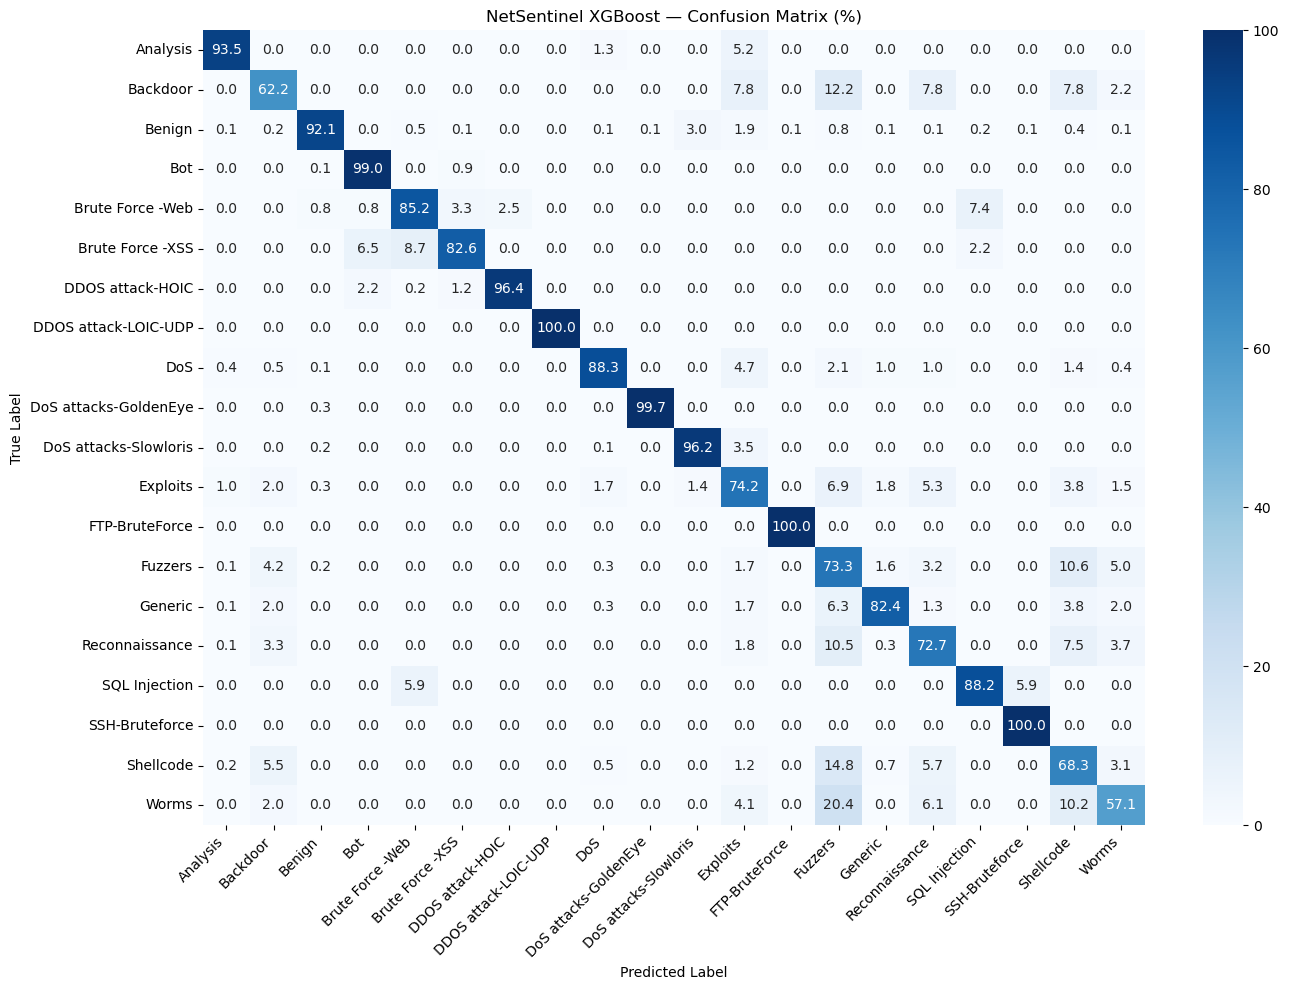

In [139]:
# ── Confusion matrix ──────────────────────────────────────────
plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title('NetSentinel XGBoost — Confusion Matrix (%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_xgboost.png', dpi=150)
plt.show()



Top 15 most important features:
ECE Flag Cnt         0.100247
Fwd PSH Flags        0.094296
PSH Flag Cnt         0.086876
Fwd Act Data Pkts    0.078649
Bwd Pkt Len Min      0.059248
RST Flag Cnt         0.053236
Tot Fwd Pkts         0.047256
SYN Flag Cnt         0.042557
Fwd Pkt Len Min      0.036921
Tot Bwd Pkts         0.036597
FIN Flag Cnt         0.035108
Down/Up Ratio        0.034689
ACK Flag Cnt         0.033690
Bwd Pkt Len Mean     0.028266
Pkt Len Min          0.020705
Bwd Pkt Len Std      0.019425
Pkt Len Max          0.017923
Idle Std             0.017677
Active Std           0.017414
TotLen Bwd Pkts      0.014826
Bwd Pkt Len Max      0.013819
Idle Mean            0.011775
Fwd Pkt Len Max      0.011339
Active Max           0.010754
TotLen Fwd Pkts      0.009344
Flow Byts/s          0.008914
Flow Pkts/s          0.007809
Fwd Pkt Len Std      0.007541
Pkt Len Mean         0.006791
Idle Max             0.006697
Idle Min             0.005222
Pkt Len Var          0.005096
Active 

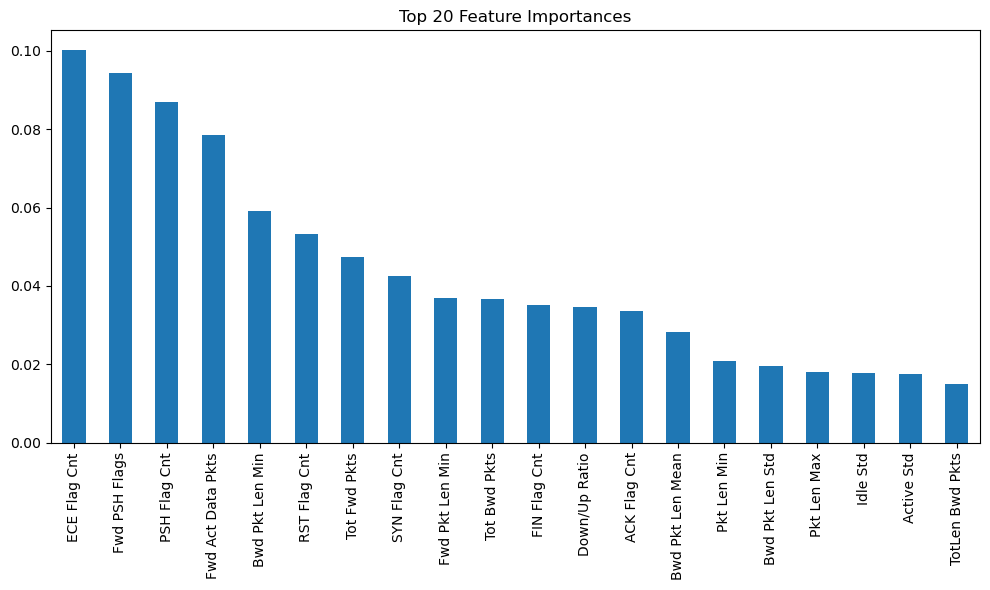

In [140]:
import os
# ── Feature importance ────────────────────────────────────────
# This tells you which of your features actually matter
# feature_names = joblib.load('feature_names.pkl') \
#    if os.path.exists('feature_names.pkl') else \
#    [f'f{i}' for i in range(X_train.shape[1])]

importances = pd.Series(
    model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("\nTop 15 most important features:")
print(importances.head(78).to_string())

plt.figure(figsize=(10, 6))
importances.head(20).plot(kind='bar')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance_xgboost.png', dpi=150)
plt.show()

In [141]:
# ══════════════════════════════════════════════════════════════
#  12. SAVE EVERYTHING
#      Same file names as your LSTM pipeline — drop-in replacement
# ══════════════════════════════════════════════════════════════

print("\n[12] Saving model and preprocessors...")

# Save XGBoost model
model.save_model('netsentinel_xgb_combined_Dataset4.json')          # native XGBoost format
joblib.dump(model, 'netsentinel_xgb_combined_Dataset4.pkl')          # sklearn-compatible

# Save scaler and encoder — same names as before so Debian pipeline works
joblib.dump(scaler, 'scaler_cpu_combined_Dataset4.pkl')
joblib.dump(le,     'label_encoder_combined_Dataset4.pkl')

# Save feature names so Scapy pipeline knows the correct order
import json
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("    netsentinel_xgb_.json     ← XGBoost model")
print("    netsentinel_xgb.pkl      ← sklearn-compatible model")
print("    scaler_cpu.pkl           ← same scaler for Debian")
print("    label_encoder_cpu.pkl    ← same encoder for Debian")
print("    feature_names.json       ← feature order for pipeline")
print("\n✅ Done — ready for deployment on Debian IDS machine")


[12] Saving model and preprocessors...
    netsentinel_xgb_.json     ← XGBoost model
    netsentinel_xgb.pkl      ← sklearn-compatible model
    scaler_cpu.pkl           ← same scaler for Debian
    label_encoder_cpu.pkl    ← same encoder for Debian
    feature_names.json       ← feature order for pipeline

✅ Done — ready for deployment on Debian IDS machine
